### Hi! we are going to do experiments on the CO2 Emmssion of Diffirent cars and we will try to improve our r2 square and RMSE as well in different ways...


## Load the Data set

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
url = "D:\CO2 Emmision project\Data set\FuelConsumptionCo2.csv"
df = pd.read_csv(url)

# Check first few rows
print(df.head())


   MODELYEAR   MAKE       MODEL VEHICLECLASS  ENGINESIZE  CYLINDERS  \
0       2014  ACURA         ILX      COMPACT         2.0          4   
1       2014  ACURA         ILX      COMPACT         2.4          4   
2       2014  ACURA  ILX HYBRID      COMPACT         1.5          4   
3       2014  ACURA     MDX 4WD  SUV - SMALL         3.5          6   
4       2014  ACURA     RDX AWD  SUV - SMALL         3.5          6   

  TRANSMISSION FUELTYPE  FUELCONSUMPTION_CITY  FUELCONSUMPTION_HWY  \
0          AS5        Z                   9.9                  6.7   
1           M6        Z                  11.2                  7.7   
2          AV7        Z                   6.0                  5.8   
3          AS6        Z                  12.7                  9.1   
4          AS6        Z                  12.1                  8.7   

   FUELCONSUMPTION_COMB  FUELCONSUMPTION_COMB_MPG  CO2EMISSIONS  
0                   8.5                        33           196  
1                   

In [22]:
# Use numeric features only for simplicity
features = ['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY']
target = 'CO2EMISSIONS'

X = df[features]
y = df[target]


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [24]:
# Create model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on test set
y_pred = lr_model.predict(X_test)


In [ ]:
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

from sklearn.metrics import mean_squared_error, r2_score

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² score: {r2:.3f}")
print(f"RMSE: {rmse:.2f} g/km")


R² score: 0.876
RMSE: 22.62 g/km


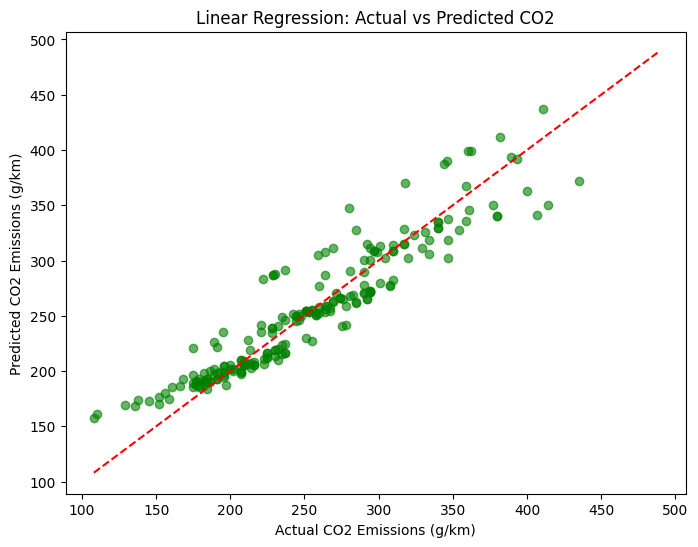

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='green')
plt.xlabel("Actual CO2 Emissions (g/km)")
plt.ylabel("Predicted CO2 Emissions (g/km)")
plt.title("Linear Regression: Actual vs Predicted CO2")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # diagonal line
plt.show()


### Now lets improve the R² and RMSE

In [27]:
# Select features
features = [
    'ENGINESIZE',
    'CYLINDERS',
    'FUELCONSUMPTION_CITY',
    'FUELCONSUMPTION_HWY',
    'VEHICLECLASS',
    'FUELTYPE'
]

X = df[features]
y = df['CO2EMISSIONS']

# Through One-hot encode categorical columns
X = pd.get_dummies(X, columns=['VEHICLECLASS', 'FUELTYPE'], drop_first=True)


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

#----------------------------

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R² score: {r2:.3f}")
print(f"RMSE: {rmse:.2f} g/km")



R² score: 0.990
RMSE: 6.57 g/km


# Note:
### The high R² is expected because CO₂ emissions are strongly derived from fuel consumption metrics. Adding vehicle class and fuel type captures regulatory and efficiency differences, significantly improving predictive accuracy

# lets see can we push more?

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# R² score
r2 = r2_score(y_test, y_pred_rf)

# RMSE (safe for all sklearn versions)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)

print(f"Random Forest R² score: {r2:.3f}")
print(f"Random Forest RMSE: {rmse:.2f} g/km")

Random Forest R² score: 0.992
Random Forest RMSE: 5.89 g/km


In [30]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

# R² score
r2 = r2_score(y_test, y_pred_xgb)

# RMSE (safe for all sklearn versions)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)

print(f"XGBoost R² score: {r2:.3f}")
print(f"XGBoost RMSE: {rmse:.2f} g/km")

XGBoost R² score: 0.995
XGBoost RMSE: 4.49 g/km


In [31]:
# Function to calculate metrics
def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse

# Evaluate all models
metrics = {
    "Linear Regression": evaluate_model(y_test, y_pred),
    "Random Forest": evaluate_model(y_test, y_pred_rf),
    "XGBoost": evaluate_model(y_test, y_pred_xgb)
}

# Convert to DataFrame for nice display
comparison_df = pd.DataFrame(metrics, index=["R²", "RMSE"])
print("Model Comparison Table:")
print(comparison_df)

Model Comparison Table:
      Linear Regression  Random Forest   XGBoost
R²             0.989569        0.99160  0.995123
RMSE           6.567336        5.89365  4.490888


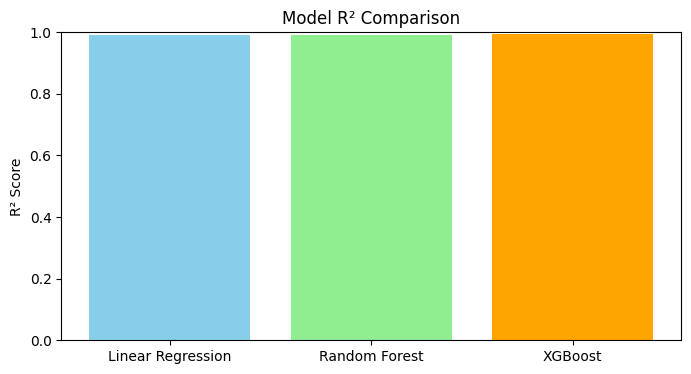

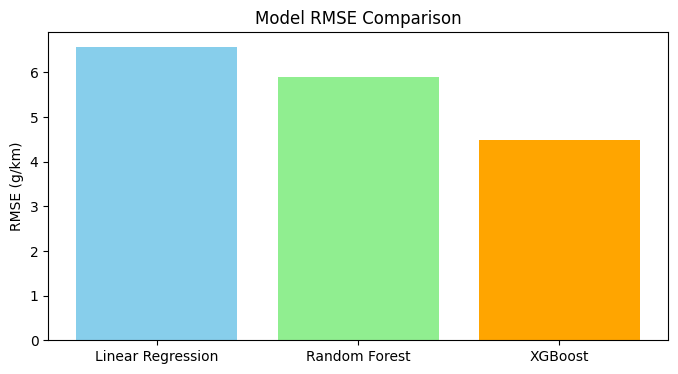

In [32]:
import matplotlib.pyplot as plt

# Bar plot for R²
plt.figure(figsize=(8, 4))
plt.bar(comparison_df.columns, comparison_df.loc["R²"], color=["skyblue", "lightgreen", "orange"])
plt.title("Model R² Comparison")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.show()

# Bar plot for RMSE
plt.figure(figsize=(8, 4))
plt.bar(comparison_df.columns, comparison_df.loc["RMSE"], color=["skyblue", "lightgreen", "orange"])
plt.title("Model RMSE Comparison")
plt.ylabel("RMSE (g/km)")
plt.show()
